#EULER PERIODIC ORBIT- SECOND ORDER SYSTEM
## ICs enforced with hard constrains
## Configuration: Bodies 1 & 2 orbit around stationary body 3

## Installation-Imports


*  first set backend
*  install libraries
*  then import modules


In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde matplotlib numpy tensorflow tf_keras

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

#TRAINING - Adjust weights using PDE Residual Losses
## Now only 6 pde terms. They are all accelaration terms.
## Second order system is better than first order since only 6 pde terms and also more balanced

Set the default float type to float64
Compiling model...
'compile' took 0.008808 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [1.21e+01, 4.27e+00, 1.17e+01, 1.85e+00, 4.45e-02, 2.70e-01]    [1.14e+01, 4.67e+00, 1.09e+01, 2.15e+00, 3.94e-02, 2.58e-01]    []  
1000      [4.27e-01, 1.99e+00, 4.31e-01, 2.09e+00, 2.82e-02, 1.64e-02]    [4.22e-01, 1.90e+00, 4.57e-01, 1.96e+00, 2.67e-02, 1.88e-02]    []  
2000      [5.64e-02, 7.36e-01, 6.09e-02, 7.68e-01, 4.33e-03, 6.32e-03]    [4.90e-02, 8.55e-01, 6.12e-02, 8.95e-01, 5.16e-03, 7.48e-03]    []  
3000      [5.26e-02, 3.77e-01, 5.56e-02, 3.89e-01, 1.51e-02, 1.61e-02]    [5.83e-02, 4.41e-01, 6.25e-02, 4.58e-01, 1.71e-02, 1.84e-02]    []  
4000      [3.98e-02, 2.66e-01, 3.67e-02, 2.63e-01, 2.10e-02, 1.12e-02]    [4.35e-02, 3.10e-01, 4.07e-02, 3.09e-01, 2.41e-02, 1.18e-02]    []  
5000      [3.18e-02, 2.01e-01, 3

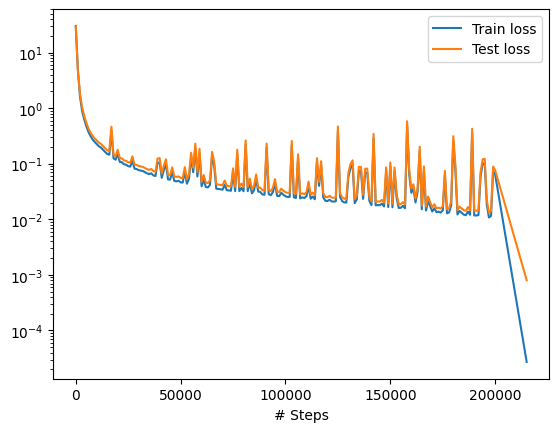

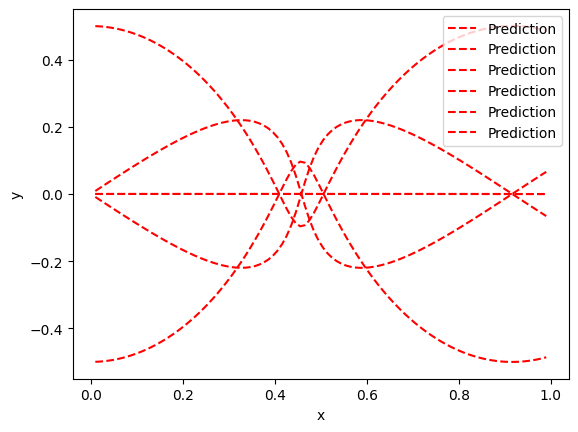

In [4]:
dde.config.set_default_float("float64")
np.random.seed(137)
tf.random.set_seed(137)

# Constants
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 1

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [128]*3 + [6]  # 6 outputs for positions only
activation = "tanh"
initializer = "Glorot uniform"
loss_weights = [1]*6
iterations = 200000
learning_rate = 1e-4
eps = 1e-9

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
# positions
x1_0, y1_0 = -0.5, 0.0
x2_0, y2_0 =  0.5, 0.0
x3_0, y3_0 =  0.0, 0.0

# velocities
vx1_0, vy1_0 = 0.0, 0.9
vx2_0, vy2_0 = 0.0, -0.9
vx3_0, vy3_0 = 0.0, 0.0

y0 = np.array([x1_0, y1_0, x2_0, y2_0,x3_0, y3_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0,vx3_0, vy3_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# Residual for second-order ODEs
# ============================================================
def three_body_ode_second(t, y):
    # r: [batch_size, 6] -> x1,y1,x2,y2,x3,y3
    x1, y1, x2, y2, x3, y3 = [y[:, i:i+1] for i in range(6)]

    # pairwise distances
    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 +eps)
    r13 = tf.sqrt((x1 - x3)**2 + (y1 - y3)**2 +eps)
    r23 = tf.sqrt((x2 - x3)**2 + (y2 - y3)**2 +eps)

    r12_3 = (r12)**3
    r13_3 = (r13)**3
    r23_3 = (r23)**3

    # accelerations
    ax1 = G*( m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3 )
    ay1 = G*( m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3 )
    ax2 = G*( m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3 )
    ay2 = G*( m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3 )
    ax3 = G*( m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3 )
    ay3 = G*( m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3 )

    # second derivatives
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)
    x3_tt = dde.grad.hessian(y, t, component=4, i=0, j=0)
    y3_tt = dde.grad.hessian(y, t, component=5, i=0, j=0)

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
        x3_tt - ax3,
        y3_tt - ay3
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)


data = dde.data.PDE(
    geom,
    three_body_ode_second,
    [],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test
)

# ============================================================
# Network and hard constraints
# ============================================================
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y

net.apply_output_transform(output_transform)

model = dde.Model(data, net)


#model.compile(
#    optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5,loss_weights=loss_weights),
#    loss="MSE",
#)
model.compile("adam", lr=learning_rate, loss_weights=loss_weights, loss="MSE")
losshistory, train_state = model.train(iterations=iterations)

model.compile("L-BFGS")  # no learning rate needed
losshistory, train_state = model.train()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
#   SAVE AND LOAD MODEL
# ============================================================
## Load the saved weights
# first - Build the network with dummy predict
#_ = model.predict(np.array([[0.0]]))
#model.restore("Euler_1nd_order_system-2000.weights.h5")
model.save("Euler_2nd_order_system")

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 + eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 + eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]


#Plots-Results

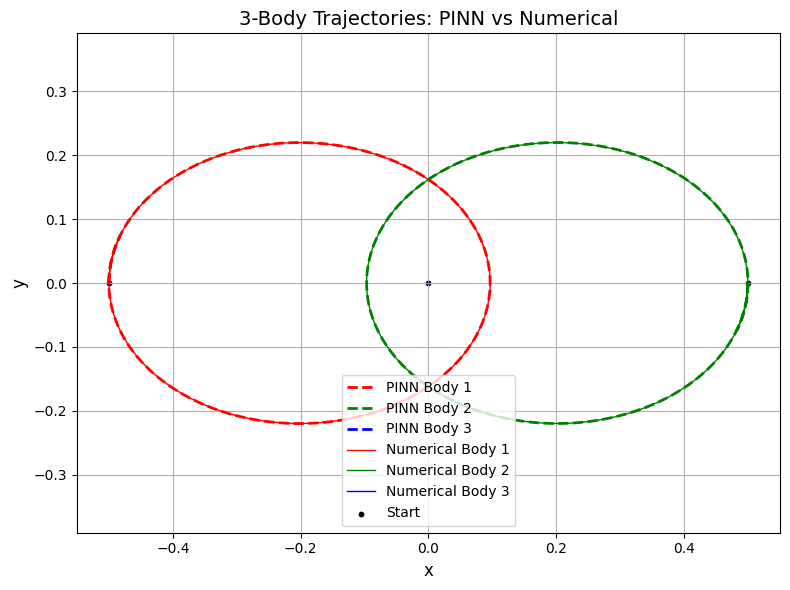


--- Relative L2 Errors (2D Position) ---
Body 1: 5.67e-04
Body 2: 7.50e-04

--- Absolute L2 Error (2D Position) ---
Body 3: 6.18e-03
(203, 6)


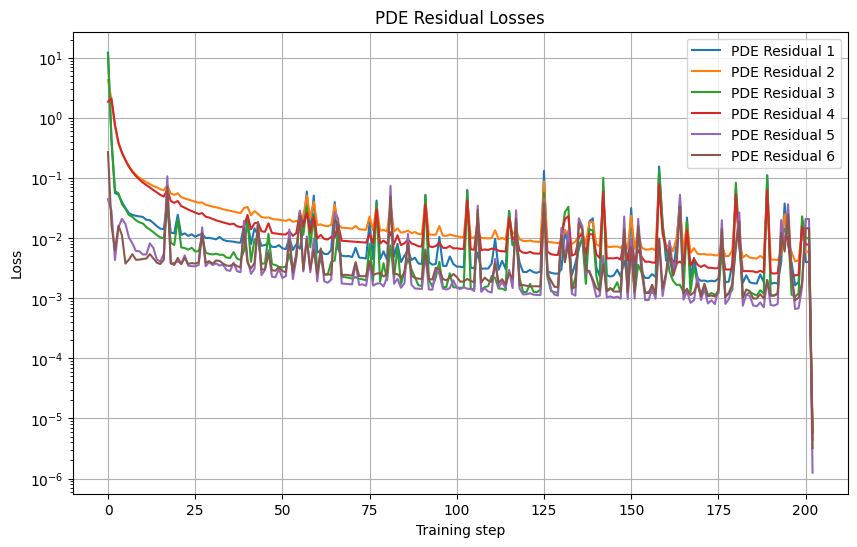

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================


# Interpolate numerical solution onto PINN time grid
interp_x1 = interp1d(t_eval, x1_n, kind="cubic")
interp_y1 = interp1d(t_eval, y1_n, kind="cubic")

interp_x2 = interp1d(t_eval, x2_n, kind="cubic")
interp_y2 = interp1d(t_eval, y2_n, kind="cubic")

interp_x3 = interp1d(t_eval, x3_n, kind="cubic")
interp_y3 = interp1d(t_eval, y3_n, kind="cubic")

# Numerical reference values at PINN times
x1_ref = interp_x1(t_test[:, 0])
y1_ref = interp_y1(t_test[:, 0])

x2_ref = interp_x2(t_test[:, 0])
y2_ref = interp_y2(t_test[:, 0])

x3_ref = interp_x3(t_test[:, 0])
y3_ref = interp_y3(t_test[:, 0])

# Stack positions into vectors [x(t), y(t)]
pinn_body1 = np.vstack((x1, y1)).T
ref_body1  = np.vstack((x1_ref, y1_ref)).T

pinn_body2 = np.vstack((x2, y2)).T
ref_body2  = np.vstack((x2_ref, y2_ref)).T

pinn_body3 = np.vstack((x3, y3)).T
ref_body3  = np.vstack((x3_ref, y3_ref)).T

# Relative L2 error over full 2D trajectory
err_body1 = norm(pinn_body1 - ref_body1) / norm(ref_body1)
err_body2 = norm(pinn_body2 - ref_body2) / norm(ref_body2)
err_body3 = norm(pinn_body3 - ref_body3)    # absolute error since body 3 not moving

print("\n--- Relative L2 Errors (2D Position) ---")
print(f"Body 1: {err_body1:.2e}")
print(f"Body 2: {err_body2:.2e}")

print("\n--- Absolute L2 Error (2D Position) ---")
print(f"Body 3: {err_body3:.2e}")



#============================ history losses per pfe res =================================
losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)


pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.semilogy(losses[:, i], label=f"PDE Residual {i+1}")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()


STATISTICS

In [6]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

LPDE = final_train_loss     # hard constraints
LDATA = 0.0

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_ref)**2 + (y1 - y1_ref)**2)
err2 = np.sqrt((x2 - x2_ref)**2 + (y2 - y2_ref)**2)
err3 = np.sqrt((x3 - x3_ref)**2 + (y3 - y3_ref)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")

# ============================================================
# BODY 3 DRIFT  - for Euler orbits
# ============================================================

body3_drift = np.max(
    np.sqrt(
        (x3 - x3[0])**2 +
        (y3 - y3[0])**2
    )
)

print("\nBody 3 drift")
print("-----------------------------")
print(f"Body 3 Drift         : {body3_drift:.2e}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")
print(f"Position RMSE       : {RMSE:.2e}")
print(f"ΔE/E0               : {DE_E0:.2e}")
print(f"Max Momentum Drift ΔP    : {DeltaP:.2e}")
print(f"ΔL/L0               : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 2.72e-05
Final Test Loss     : 8.05e-04
PDE Residual Loss   : 2.72e-05
Data Loss           : 0.00e+00

Position RMSE
-----------------------------
Body 1 : 2.26e-04
Body 2 : 2.98e-04
Body 3 : 8.75e-05
Global : 2.22e-04

Maximum Position Error
-----------------------------
Body 1 : 4.26e-04
Body 2 : 7.99e-04
Body 3 : 3.30e-04

Energy Conservation
-----------------------------
PINN ΔE/E0 : 7.74e-04
-----------------------------
Numerical ΔE/E0 : 9.99e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 2.65e-04
-----------------------------
Numerical Max Momentum Drift : 0.00e+00

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 3.66e-04

Body 3 drift
-----------------------------
Body 3 Drift         : 3.30e-04


SUMMARY
Final Training Loss : 2.72e-05
Final Test Loss     : 8.05e-04
PDE Residual Loss   : 2.72e-05
Data Loss           : 0.00e+00
Position RMSE       : 2.22e-04
ΔE/E0               : 7.74e-04
Max Mo

#Extrapolate for 1/2 of  Period

======================= Extrapolating for  1/2 of period ===============================


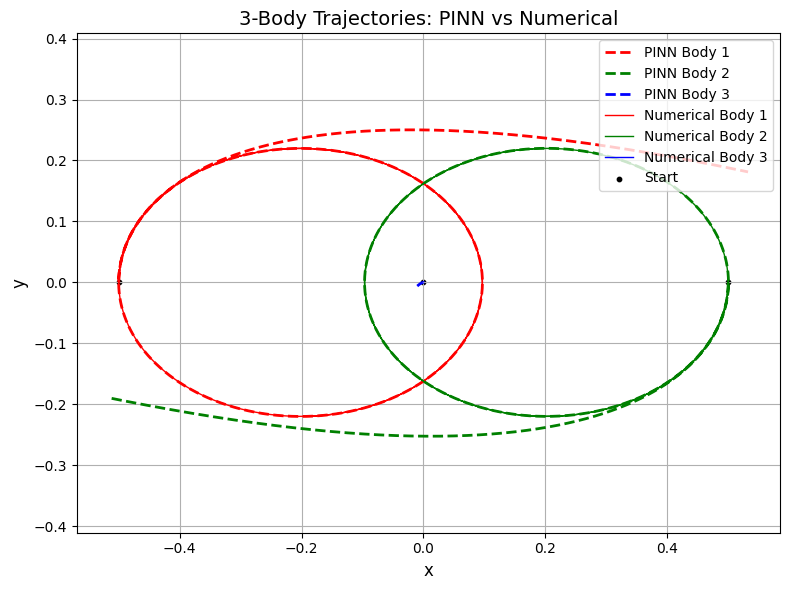


--- Relative L2 Errors (2D Position) ---
Body 1: 4.42e-01
Body 2: 4.39e-01

--- Absolute L2 Error (2D Position) ---
Body 3: 1.92e-01


In [7]:
print("===================================================================================")
print("======================= Extrapolating for  1/2 of period ===============================")
print("===================================================================================")

endTime=1+1/2

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 + eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 + eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================


# Interpolate numerical solution onto PINN time grid
interp_x1 = interp1d(t_eval, x1_n, kind="cubic")
interp_y1 = interp1d(t_eval, y1_n, kind="cubic")

interp_x2 = interp1d(t_eval, x2_n, kind="cubic")
interp_y2 = interp1d(t_eval, y2_n, kind="cubic")

interp_x3 = interp1d(t_eval, x3_n, kind="cubic")
interp_y3 = interp1d(t_eval, y3_n, kind="cubic")

# Numerical reference values at PINN times
x1_ref = interp_x1(t_test[:, 0])
y1_ref = interp_y1(t_test[:, 0])

x2_ref = interp_x2(t_test[:, 0])
y2_ref = interp_y2(t_test[:, 0])

x3_ref = interp_x3(t_test[:, 0])
y3_ref = interp_y3(t_test[:, 0])

# Stack positions into vectors [x(t), y(t)]
pinn_body1 = np.vstack((x1, y1)).T
ref_body1  = np.vstack((x1_ref, y1_ref)).T

pinn_body2 = np.vstack((x2, y2)).T
ref_body2  = np.vstack((x2_ref, y2_ref)).T

pinn_body3 = np.vstack((x3, y3)).T
ref_body3  = np.vstack((x3_ref, y3_ref)).T

# Relative L2 error over full 2D trajectory
err_body1 = norm(pinn_body1 - ref_body1) / norm(ref_body1)
err_body2 = norm(pinn_body2 - ref_body2) / norm(ref_body2)
err_body3 = norm(pinn_body3 - ref_body3)    # absolute error since body 3 not moving

print("\n--- Relative L2 Errors (2D Position) ---")
print(f"Body 1: {err_body1:.2e}")
print(f"Body 2: {err_body2:.2e}")

print("\n--- Absolute L2 Error (2D Position) ---")
print(f"Body 3: {err_body3:.2e}")


